# Load data

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os
import glob
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a temporary local folder on Colab's fast disk
local_dir = '/content/local_csvs'
os.makedirs(local_dir, exist_ok=True)

# 2. Find the files on your Google Drive (Added /*.csv to find the files)
drive_paths = glob.glob('/content/drive/MyDrive/deep-learning/DL4AI_Project_Data/nasdaq-data/*.csv')

# 3. Copy the first 30 files over to the local Colab environment (Fixed the slice to [:30])
print("Copying files to local storage...")
for file in drive_paths[:300]:
    shutil.copy(file, local_dir)

# 4. Read the files into pandas from the local folder
local_paths = glob.glob(f'{local_dir}/*.csv')
company_data_list = [pd.read_csv(file) for file in local_paths]

print(f"Successfully loaded {len(company_data_list)} companies!")

Mounted at /content/drive
Copying files to local storage...
Successfully loaded 300 companies!


# Task 1.1

## Preprocessing data

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

window_size = 30
# Select multiple features as required by Task 1.1
features = ['Low', 'High', 'Open', 'Close', 'Adjusted Close', 'Volume']
target_idx = features.index('Open') # We will predict the 'Open' price

X_train_list, y_train_list = [], []
X_val_list, y_val_list = [], []
X_test_list, y_test_list = [], []

# Process each company independently to prevent mixing time-series
for df in company_data_list:
    # Ensure data is sorted by date if a Date column exists
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
        df = df.sort_values('Date').reset_index(drop=True)

    data = df[features].values
    X_company, y_company = [], []

    # Create time windows
    for i in range(len(data) - window_size):
        X_company.append(data[i : i + window_size])
        y_company.append(data[i + window_size, target_idx])

    X_company = np.array(X_company)
    y_company = np.array(y_company)

    # Split sequentially (60% Train, 20% Val, 20% Test)
    n = len(X_company)
    train_end = int(n * 0.6)
    val_end = int(n * 0.8)

    X_train_list.append(X_company[:train_end])
    y_train_list.append(y_company[:train_end])
    X_val_list.append(X_company[train_end:val_end])
    y_val_list.append(y_company[train_end:val_end])
    X_test_list.append(X_company[val_end:])
    y_test_list.append(y_company[val_end:])

# Concatenate all companies
X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)
X_val = np.concatenate(X_val_list, axis=0)
y_val = np.concatenate(y_val_list, axis=0)
X_test = np.concatenate(X_test_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)

# ----------------- Normalization -----------------
# We reshape to 2D to apply MinMaxScaler, then reshape back to 3D
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit only on training data to prevent data leakage
X_train_scaled = scaler_X.fit_transform(X_train.reshape(-1, len(features))).reshape(X_train.shape)
X_val_scaled = scaler_X.transform(X_val.reshape(-1, len(features))).reshape(X_val.shape)
X_test_scaled = scaler_X.transform(X_test.reshape(-1, len(features))).reshape(X_test.shape)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

print(f"X_train scaled shape: {X_train_scaled.shape}")

X_train scaled shape: (1071782, 30, 6)


## LSTM

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2

# 1. Simple architecture
model = Sequential([
    Input(shape=(window_size, len(features))),

    # Single LSTM layer with L2 regularization to prevent overfitting
    LSTM(50, return_sequences=False, kernel_regularizer=l2(0.001)),

    # Heavier dropout to force the network to rely on multiple features
    Dropout(0.3),

    # Compact dense layer
    Dense(20, activation='relu'),
    Dense(1)
])

# 2. Use Huber Loss and a smaller learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(optimizer=optimizer,
              loss=tf.keras.losses.Huber(),
              metrics=['mae', 'mse'])

# 3. Add Early Stopping to halt training if validation loss stops improving
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,          # Stop if no improvement for 5 epochs
    restore_best_weights=True # Revert to the best epoch's weights
)

print("Starting training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,        # Increased epochs since Early Stopping will catch it
    batch_size=64,
    callbacks=[early_stopping]
)

Starting training...
Epoch 1/30
1848/1848 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 0.0031 - mae: 0.0258 - mse: 0.0022 - val_loss: 0.0176 - val_mae: 0.0782 - val_mse: 0.0384
Epoch 2/30
1848/1848 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 4.9287e-04 - mae: 0.0182 - mse: 7.0903e-04 - val_loss: 0.0092 - val_mae: 0.0955 - val_mse: 0.0182
Epoch 3/30
1848/1848 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 3.3362e-04 - mae: 0.0160 - mse: 5.3759e-04 - val_loss: 0.0146 - val_mae: 0.1244 - val_mse: 0.0292
Epoch 4/30
1848/1848 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 2.7604e-04 - mae: 0.0149 - mse: 4.5430e-04 - val_loss: 0.0102 - val_mae: 0.1046 - val_mse: 0.0203
Epoch 5/30
1848/1848 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 2.3483e-04 - mae: 0.0136 - mse: 3.8731e-04 - val_loss: 0.0139 - val_mae: 0.1260 - val_mse: 0.0277
Epoch 6/30
1848/1848 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 2.0526e-04 - mae: 0.0127 - mse: 3.3985e-04 - val_loss: 0.0156 - val_mae: 0.1316 - val_mse: 0.0311
Epoch 7/30
1848/1848

1214/1214 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Test MSE: 189887161.8168
Test MAE: 1693.8708
Directional Accuracy: 49.52%


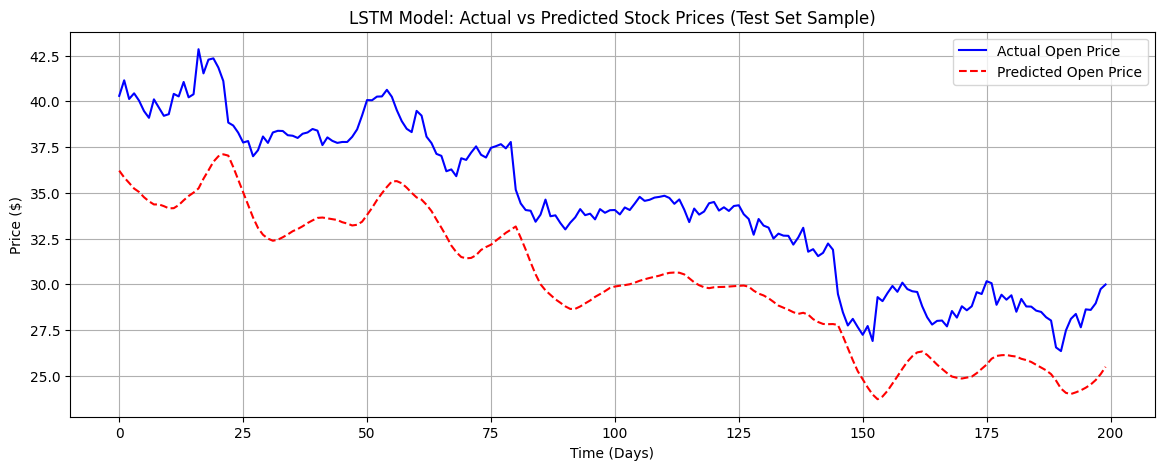

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score

# 1. Generate predictions in scaled format
y_pred_scaled = model.predict(X_test)

y_pred_actual = []
y_test_actual = []

current_idx = 0
# 2. Un-scale the predictions per company
for scaler_y, num_samples in test_scalers:
    if num_samples <= 0: continue

    # Slice the predictions belonging to this specific company
    company_y_pred_scaled = y_pred_scaled[current_idx : current_idx + num_samples]
    company_y_test_scaled = y_test[current_idx : current_idx + num_samples]

    # Inverse transform using this company's unique scaler
    company_y_pred = scaler_y.inverse_transform(company_y_pred_scaled)
    company_y_test = scaler_y.inverse_transform(company_y_test_scaled)

    y_pred_actual.extend(company_y_pred)
    y_test_actual.extend(company_y_test)

    current_idx += num_samples

y_pred_actual = np.array(y_pred_actual)
y_test_actual = np.array(y_test_actual)

# 3. Regression Evaluation
mse = mean_squared_error(y_test_actual, y_pred_actual)
mae = mean_absolute_error(y_test_actual, y_pred_actual)
print(f"Test MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")

# 4. Directional Accuracy
actual_direction = (y_test_actual[1:] > y_test_actual[:-1]).astype(int)
predicted_direction = (y_pred_actual[1:] > y_test_actual[:-1]).astype(int)

dir_acc = accuracy_score(actual_direction, predicted_direction)
print(f"Directional Accuracy: {dir_acc * 100:.2f}%")

# 5. Visualization (Plotting the first 200 days of the first company's test set)
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual[:200], color='blue', label='Actual Open Price')
plt.plot(y_pred_actual[:200], color='red', linestyle='dashed', label='Predicted Open Price')
plt.title('LSTM Model: Actual vs Predicted Stock Prices (Test Set Sample)')
plt.xlabel('Time (Days)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

## Second try with LSTM

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

window_size = 30
features = ['Low', 'High', 'Open', 'Close', 'Adjusted Close', 'Volume']
target_idx = features.index('Open')

X_train_list, y_train_list = [], []
X_val_list, y_val_list = [], []
X_test_list, y_test_list = [], []

test_scalers = []
test_previous_prices = []

for df in company_data_list:
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
        df = df.sort_values('Date').reset_index(drop=True)

    # 1. Extract the raw Open prices before converting to percentages
    raw_open_prices = df['Open'].values

    # 2. Convert all features to Daily Percentage Change
    df_returns = df[features].pct_change()

    df_returns.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Add the raw open prices back in as a reference column
    df_returns['Raw_Open'] = raw_open_prices

    # Drop the first row (NaN from pct_change) AND any rows that had infinity/NaN
    df_returns = df_returns.dropna()

    if len(df_returns) < window_size + 10:
        continue

    n = len(df_returns)
    train_end = int(n * 0.6)
    val_end = int(n * 0.8)

    # Split data
    train_data = df_returns[features].iloc[:train_end].values
    val_data = df_returns[features].iloc[train_end:val_end].values
    test_data = df_returns[features].iloc[val_end:].values

    # Save yesterday's actual prices for the Test set
    test_raw_prices = df_returns['Raw_Open'].iloc[val_end:].values

    # Scale Features
    scaler_X = StandardScaler()
    train_X_scaled = scaler_X.fit_transform(train_data)
    val_X_scaled = scaler_X.transform(val_data)
    test_X_scaled = scaler_X.transform(test_data)

    # Scale Target
    scaler_y = StandardScaler()
    train_y_scaled = scaler_y.fit_transform(train_data[:, target_idx].reshape(-1, 1))
    val_y_scaled = scaler_y.transform(val_data[:, target_idx].reshape(-1, 1))
    test_y_scaled = scaler_y.transform(test_data[:, target_idx].reshape(-1, 1))

    num_test_samples = len(test_X_scaled) - window_size
    if num_test_samples > 0:
        test_scalers.append((scaler_y, num_test_samples))
        test_previous_prices.extend(test_raw_prices[window_size - 1 : -1])

    # Build windows
    for i in range(len(train_X_scaled) - window_size):
        X_train_list.append(train_X_scaled[i : i + window_size])
        y_train_list.append(train_y_scaled[i + window_size])

    for i in range(len(val_X_scaled) - window_size):
        X_val_list.append(val_X_scaled[i : i + window_size])
        y_val_list.append(val_y_scaled[i + window_size])

    for i in range(len(test_X_scaled) - window_size):
        X_test_list.append(test_X_scaled[i : i + window_size])
        y_test_list.append(test_y_scaled[i + window_size])

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)
X_val = np.array(X_val_list)
y_val = np.array(y_val_list)
X_test = np.array(X_test_list)
y_test = np.array(y_test_list)
test_previous_prices = np.array(test_previous_prices)

print(f"X_train scaled shape: {X_train.shape}")

/tmp/ipykernel_7592/1744661935.py:25: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_returns = df[features].pct_change()
/tmp/ipykernel_7592/1744661935.py:25: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_returns = df[features].pct_change()


X_train scaled shape: (999174, 30, 6)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2

# 1. Simplified, robust architecture
model = Sequential([
    Input(shape=(window_size, len(features))),

    # Single LSTM layer with L2 regularization to prevent overfitting
    LSTM(50, return_sequences=False, kernel_regularizer=l2(0.001)),

    # Heavier dropout to force the network to rely on multiple features
    Dropout(0.3),

    # Compact dense layer
    Dense(20, activation='relu'),
    Dense(1)
])

# 2. Use Huber Loss and a slightly smaller learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(optimizer=optimizer,
              loss=tf.keras.losses.Huber(), # Highly recommended for stocks
              metrics=['mae', 'mse'])

# 3. Add Early Stopping to halt training if validation loss stops improving
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,          # Stop if no improvement for 5 epochs
    restore_best_weights=True # Revert to the best epoch's weights
)

print("Starting training...")
history = model.fit(
    X_train, y_train, # Ensure you are using the PER-COMPANY scaled data from the previous step
    validation_data=(X_val, y_val),
    epochs=30,        # Increased epochs since Early Stopping will catch it
    batch_size=256,
    callbacks=[early_stopping]
)

Starting training...
Epoch 1/30
3904/3904 ━━━━━━━━━━━━━━━━━━━━ 54s 13ms/step - loss: 0.1513 - mae: 0.3738 - mse: 0.4206 - val_loss: 0.0822 - val_mae: 0.2520 - val_mse: 0.2793
Epoch 2/30
3904/3904 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - loss: 0.1405 - mae: 0.3597 - mse: 0.3939 - val_loss: 0.0808 - val_mae: 0.2506 - val_mse: 0.2753
Epoch 3/30
3904/3904 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 0.1387 - mae: 0.3574 - mse: 0.3895 - val_loss: 0.0800 - val_mae: 0.2490 - val_mse: 0.2749
Epoch 4/30
3904/3904 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - loss: 0.1379 - mae: 0.3564 - mse: 0.3877 - val_loss: 0.0797 - val_mae: 0.2489 - val_mse: 0.2730
Epoch 5/30
3904/3904 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 0.1372 - mae: 0.3555 - mse: 0.3855 - val_loss: 0.0800 - val_mae: 0.2518 - val_mse: 0.2737
Epoch 6/30
3904/3904 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 0.1368 - mae: 0.3548 - mse: 0.3848 - val_loss: 0.0792 - val_mae: 0.2480 - val_mse: 0.2740
Epoch 7/30
3904/3904 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - los

10226/10226 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step
Directional Accuracy: 83.07%
Test MSE: 1.8232
Test MAE: 0.4166


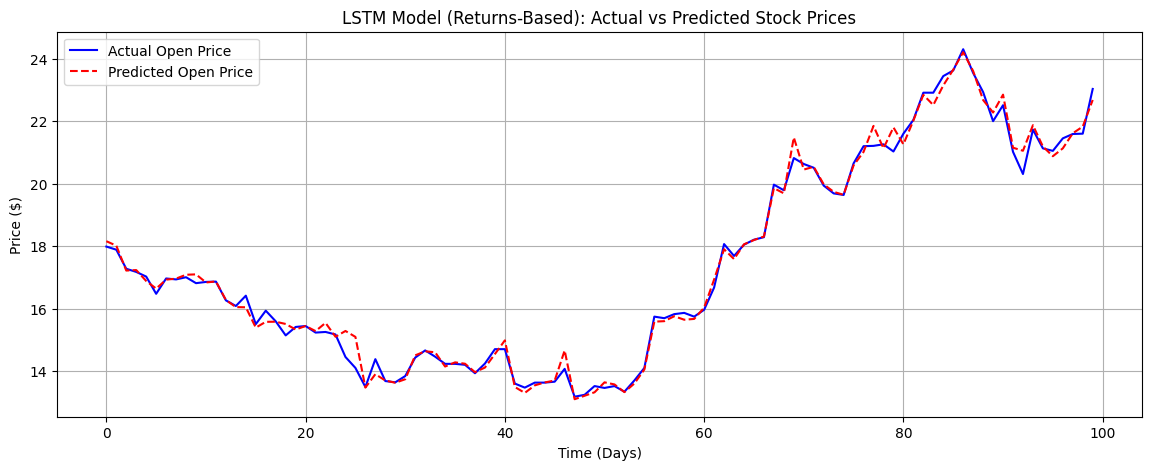

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score
import matplotlib.pyplot as plt

# 1. Generate return predictions
y_pred_scaled = model.predict(X_test)

y_pred_returns = []
y_test_returns = []

current_idx = 0
# 2. Un-scale the returns per company
for scaler_y, num_samples in test_scalers:
    if num_samples <= 0: continue

    company_y_pred_scaled = y_pred_scaled[current_idx : current_idx + num_samples]
    company_y_test_scaled = y_test[current_idx : current_idx + num_samples]

    company_y_pred = scaler_y.inverse_transform(company_y_pred_scaled)
    company_y_test = scaler_y.inverse_transform(company_y_test_scaled)

    y_pred_returns.extend(company_y_pred)
    y_test_returns.extend(company_y_test)

    current_idx += num_samples

y_pred_returns = np.array(y_pred_returns).flatten()
y_test_returns = np.array(y_test_returns).flatten()

# 3. Directional Accuracy (Did it predict the correct sign: + or - ?)
actual_direction = (y_test_returns > 0).astype(int)
predicted_direction = (y_pred_returns > 0).astype(int)

dir_acc = accuracy_score(actual_direction, predicted_direction)
print(f"Directional Accuracy: {dir_acc * 100:.2f}%")

# 4. Reconstruct absolute prices for MSE/MAE evaluation
# Formula: Price_Today = Price_Yesterday * (1 + Return_Today)
predicted_prices = test_previous_prices * (1 + y_pred_returns)
actual_prices = test_previous_prices * (1 + y_test_returns)

mse = mean_squared_error(actual_prices, predicted_prices)
mae = mean_absolute_error(actual_prices, predicted_prices)
print(f"Test MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")

# 5. Visualization (Plotting the first 100 days of the first company)
plt.figure(figsize=(14, 5))
plt.plot(actual_prices[:100], color='blue', label='Actual Open Price')
plt.plot(predicted_prices[:100], color='red', linestyle='dashed', label='Predicted Open Price')
plt.title('LSTM Model (Returns-Based): Actual vs Predicted Stock Prices')
plt.xlabel('Time (Days)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

# Task 1.2

## Preprocessing data

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2

# --- TASK 1.2 CONFIGURATION ---
window_size = 30
k = 3 # Forecast horizon: Predict the 3rd day ahead (Change to 7 for 7th day)
features = ['Low', 'High', 'Open', 'Close', 'Adjusted Close', 'Volume']

X_train_list, y_train_list = [], []
X_val_list, y_val_list = [], []
X_test_list, y_test_list, test_previous_prices = [], [], []
test_scalers = []

print(f"Preparing data to predict {k} days into the future...")

for df in company_data_list:
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
        df = df.sort_values('Date').reset_index(drop=True)

    raw_open_prices = df['Open'].values

    # 1. Features: 1-day returns
    df_features = df[features].pct_change(fill_method=None)
    df_features.replace([np.inf, -np.inf], np.nan, inplace=True)

    # 2. Target: Cumulative k-day return
    # This calculates the return from Day T to Day T+k
    df_features['Target_Return'] = df['Open'].pct_change(periods=k,fill_method=None)
    df_features['Raw_Open'] = raw_open_prices

    # Run the infinity cleanup AFTER all pct_change() calculations are done!
    df_features.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Drop NaNs caused by the shifts
    df_features = df_features.dropna()

    if len(df_features) < window_size + k + 10:
        continue

    feature_cols = [df_features.columns.get_loc(c) for c in features]
    target_idx = df_features.columns.get_loc('Target_Return')
    raw_idx = df_features.columns.get_loc('Raw_Open')

    data_array = df_features.values

    n = len(data_array)
    train_end = int(n * 0.6)
    val_end = int(n * 0.8)

    train_data = data_array[:train_end]
    val_data = data_array[train_end:val_end]
    test_data = data_array[val_end:]

    # Scale Features
    scaler_X = StandardScaler()
    train_X_scaled = scaler_X.fit_transform(train_data[:, feature_cols])
    val_X_scaled = scaler_X.transform(val_data[:, feature_cols])
    test_X_scaled = scaler_X.transform(test_data[:, feature_cols])

    # Scale Target (The k-day return)
    scaler_y = StandardScaler()
    train_y_scaled = scaler_y.fit_transform(train_data[:, target_idx].reshape(-1, 1))
    val_y_scaled = scaler_y.transform(val_data[:, target_idx].reshape(-1, 1))
    test_y_scaled = scaler_y.transform(test_data[:, target_idx].reshape(-1, 1))

    # Track scalers and raw prices for the test set
    num_test_samples = len(test_X_scaled) - window_size - k + 1
    if num_test_samples > 0:
        test_scalers.append((scaler_y, num_test_samples))

    # --- BUILD TIME WINDOWS ---
    # Subtract (k - 1) to ensure we have future data available for the target
    for i in range(len(train_X_scaled) - window_size - k + 1):
        X_train_list.append(train_X_scaled[i : i + window_size])
        y_train_list.append(train_y_scaled[i + window_size + k - 1])

    for i in range(len(val_X_scaled) - window_size - k + 1):
        X_val_list.append(val_X_scaled[i : i + window_size])
        y_val_list.append(val_y_scaled[i + window_size + k - 1])

    for i in range(len(test_X_scaled) - window_size - k + 1):
        X_test_list.append(test_X_scaled[i : i + window_size])
        y_test_list.append(test_y_scaled[i + window_size + k - 1])
        # Save the actual raw price at the END of this specific 30-day window
        test_previous_prices.append(test_data[i + window_size - 1, raw_idx])

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)
X_val = np.array(X_val_list)
y_val = np.array(y_val_list)
X_test = np.array(X_test_list)
y_test = np.array(y_test_list)
test_previous_prices = np.array(test_previous_prices)

print(f"Data ready! X_train shape: {X_train.shape}")

Preparing data to predict 3 days into the future...
Data ready! X_train shape: (998114, 30, 6)


## LSTM

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2

# --- 1. Model Architecture ---
model = Sequential([
    Input(shape=(window_size, len(features))),
    LSTM(50, return_sequences=False, kernel_regularizer=l2(0.001)),
    Dropout(0.2), # Slightly reduced dropout to give the model more breathing room
    Dense(20, activation='relu'),
    Dense(1)
])

# --- 2. Gradient Clipping inside the Optimizer ---
# We start with a slightly higher LR (0.001) because the scheduler will reduce it later
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)

model.compile(optimizer=optimizer,
              loss=tf.keras.losses.Huber(),
              metrics=['mae'])

# --- 3. Callbacks (Early Stopping + LR Scheduler) ---
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6, # Slightly higher patience so it doesn't stop before the LR scheduler kicks in
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # Halve the learning rate
    patience=2,      # If val_loss doesn't improve for 2 epochs, trigger the reduction
    min_lr=1e-6,     # Never drop the LR below this threshold
    verbose=1        # Prints a message when the LR is reduced
)

print(f"Training optimized model for {k}-day forecast...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,       # Increased max epochs to let the scheduler do its work
    batch_size=64,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

Training optimized model for 3-day forecast...
Epoch 1/40
15596/15596 ━━━━━━━━━━━━━━━━━━━━ 155s 10ms/step - loss: 0.2819 - mae: 0.5792 - val_loss: 0.1905 - val_mae: 0.4507 - learning_rate: 0.0010
Epoch 2/40
15596/15596 ━━━━━━━━━━━━━━━━━━━━ 148s 9ms/step - loss: 0.2797 - mae: 0.5770 - val_loss: 0.1901 - val_mae: 0.4508 - learning_rate: 0.0010
Epoch 3/40
15596/15596 ━━━━━━━━━━━━━━━━━━━━ 140s 9ms/step - loss: 0.2793 - mae: 0.5765 - val_loss: 0.1898 - val_mae: 0.4494 - learning_rate: 0.0010
Epoch 4/40
15596/15596 ━━━━━━━━━━━━━━━━━━━━ 140s 9ms/step - loss: 0.2790 - mae: 0.5761 - val_loss: 0.1892 - val_mae: 0.4491 - learning_rate: 0.0010
Epoch 5/40
15596/15596 ━━━━━━━━━━━━━━━━━━━━ 139s 9ms/step - loss: 0.2787 - mae: 0.5758 - val_loss: 0.1904 - val_mae: 0.4514 - learning_rate: 0.0010
Epoch 6/40
15591/15596 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2786 - mae: 0.5754
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
15596/15596 ━━━━━━━━━━━━━━━━━━━━ 143s 9ms/step - lo

1185/1185 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Directional Accuracy (3-Day Horizon): 65.77%
Test MSE (3-Day Horizon): 27.0576
Test MAE (3-Day Horizon): 2.5333


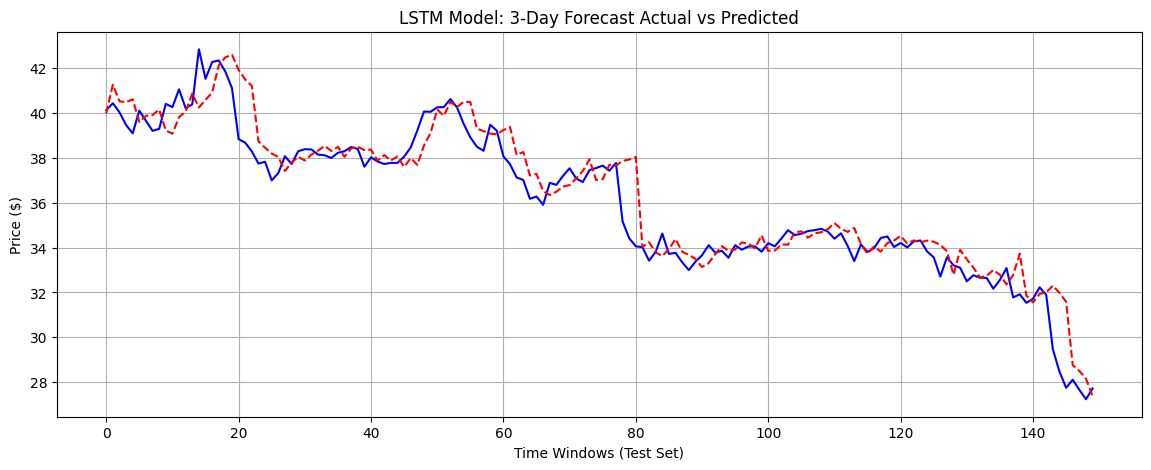

In [ ]:
# 1. Generate return predictions for the k-th day
y_pred_scaled = model.predict(X_test)

y_pred_returns, y_test_returns = [], []
current_idx = 0

# 2. Un-scale the returns per company
for scaler_y, num_samples in test_scalers:
    if num_samples <= 0: continue

    company_y_pred_scaled = y_pred_scaled[current_idx : current_idx + num_samples]
    company_y_test_scaled = y_test[current_idx : current_idx + num_samples]

    company_y_pred = scaler_y.inverse_transform(company_y_pred_scaled)
    company_y_test = scaler_y.inverse_transform(company_y_test_scaled)

    y_pred_returns.extend(company_y_pred)
    y_test_returns.extend(company_y_test)
    current_idx += num_samples

y_pred_returns = np.array(y_pred_returns).flatten()
y_test_returns = np.array(y_test_returns).flatten()

# 3. Directional Accuracy (Over the k-day horizon)
actual_direction = (y_test_returns > 0).astype(int)
predicted_direction = (y_pred_returns > 0).astype(int)

dir_acc = accuracy_score(actual_direction, predicted_direction)
print(f"Directional Accuracy ({k}-Day Horizon): {dir_acc * 100:.2f}%")

# 4. Reconstruct absolute prices for the k-th day
# Price_Future = Price_Current * (1 + Return_k)
predicted_prices = test_previous_prices * (1 + y_pred_returns)
actual_prices = test_previous_prices * (1 + y_test_returns)

mse = mean_squared_error(actual_prices, predicted_prices)
mae = mean_absolute_error(actual_prices, predicted_prices)
print(f"Test MSE ({k}-Day Horizon): {mse:.4f}")
print(f"Test MAE ({k}-Day Horizon): {mae:.4f}")

# 5. Visualization
plt.figure(figsize=(14, 5))
plt.plot(actual_prices[:150], color='blue', label=f'Actual Price (Day + {k})')
plt.plot(predicted_prices[:150], color='red', linestyle='dashed', label=f'Predicted Price (Day + {k})')
plt.title(f'LSTM Model: {k}-Day Forecast Actual vs Predicted')
plt.xlabel('Time Windows (Test Set)')
plt.ylabel('Price ($)')
plt.grid(True)
plt.show()

10203/10203 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step
Directional Accuracy (3-Day Horizon): 66.87%
Test MSE (3-Day Horizon): 11.3328
Test MAE (3-Day Horizon): 1.2640


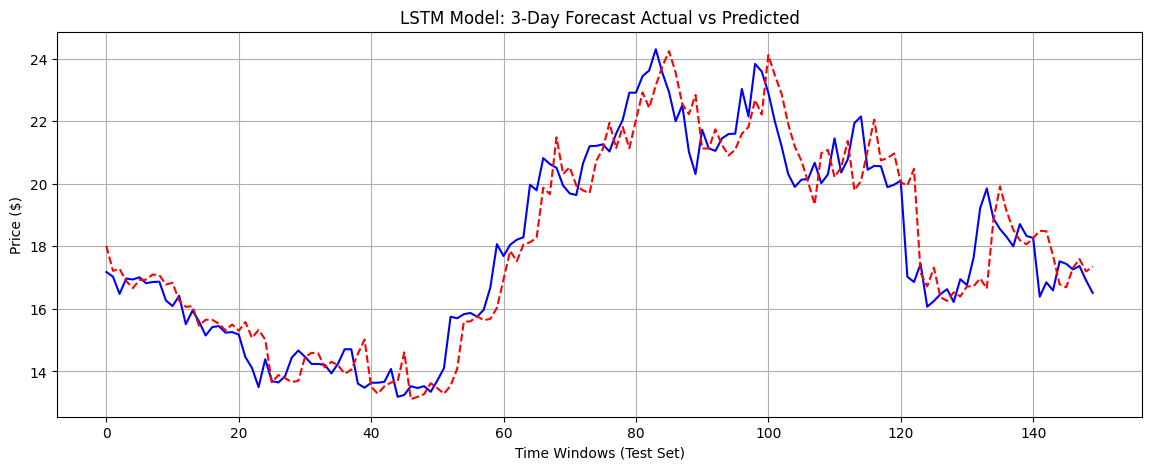

In [ ]:
# 1. Generate return predictions for the k-th day with 300 tickets
y_pred_scaled = model.predict(X_test)

y_pred_returns, y_test_returns = [], []
current_idx = 0

# 2. Un-scale the returns per company
for scaler_y, num_samples in test_scalers:
    if num_samples <= 0: continue

    company_y_pred_scaled = y_pred_scaled[current_idx : current_idx + num_samples]
    company_y_test_scaled = y_test[current_idx : current_idx + num_samples]

    company_y_pred = scaler_y.inverse_transform(company_y_pred_scaled)
    company_y_test = scaler_y.inverse_transform(company_y_test_scaled)

    y_pred_returns.extend(company_y_pred)
    y_test_returns.extend(company_y_test)
    current_idx += num_samples

y_pred_returns = np.array(y_pred_returns).flatten()
y_test_returns = np.array(y_test_returns).flatten()

# 3. Directional Accuracy (Over the k-day horizon)
actual_direction = (y_test_returns > 0).astype(int)
predicted_direction = (y_pred_returns > 0).astype(int)

dir_acc = accuracy_score(actual_direction, predicted_direction)
print(f"Directional Accuracy ({k}-Day Horizon): {dir_acc * 100:.2f}%")

# 4. Reconstruct absolute prices for the k-th day
# Price_Future = Price_Current * (1 + Return_k)
predicted_prices = test_previous_prices * (1 + y_pred_returns)
actual_prices = test_previous_prices * (1 + y_test_returns)

mse = mean_squared_error(actual_prices, predicted_prices)
mae = mean_absolute_error(actual_prices, predicted_prices)
print(f"Test MSE ({k}-Day Horizon): {mse:.4f}")
print(f"Test MAE ({k}-Day Horizon): {mae:.4f}")

# 5. Visualization
plt.figure(figsize=(14, 5))
plt.plot(actual_prices[:150], color='blue', label=f'Actual Price (Day + {k})')
plt.plot(predicted_prices[:150], color='red', linestyle='dashed', label=f'Predicted Price (Day + {k})')
plt.title(f'LSTM Model: {k}-Day Forecast Actual vs Predicted')
plt.xlabel('Time Windows (Test Set)')
plt.ylabel('Price ($)')
plt.grid(True)
plt.show()

# Task 1.3

## LSTM

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

# --- TASK 1.3 CONFIGURATION ---
window_size = 30
k = 3 # Forecast horizon: Predict the next 3 consecutive days
features = ['Low', 'High', 'Open', 'Close', 'Adjusted Close', 'Volume']

X_train_list, y_train_list = [], []
X_val_list, y_val_list = [], []
X_test_list, y_test_list, test_previous_prices = [], [], []
test_scalers = []

print(f"Preparing data to predict {k} consecutive days...")

for df in company_data_list:
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
        df = df.sort_values('Date').reset_index(drop=True)

    raw_open_prices = df['Open'].values

    # 1. Calculate 1-day returns
    df_features = df[features].pct_change(fill_method=None)
    df_features['Raw_Open'] = raw_open_prices

    # Cleanup
    df_features.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_features = df_features.dropna()

    if len(df_features) < window_size + k + 10:
        continue

    feature_cols = [df_features.columns.get_loc(c) for c in features]
    target_idx = df_features.columns.get_loc('Open') # The return of the Open price
    raw_idx = df_features.columns.get_loc('Raw_Open')

    data_array = df_features.values
    n = len(data_array)
    train_end = int(n * 0.6)
    val_end = int(n * 0.8)

    train_data = data_array[:train_end]
    val_data = data_array[train_end:val_end]
    test_data = data_array[val_end:]

    scaler_X = StandardScaler()
    train_X_scaled = scaler_X.fit_transform(train_data[:, feature_cols])
    val_X_scaled = scaler_X.transform(val_data[:, feature_cols])
    test_X_scaled = scaler_X.transform(test_data[:, feature_cols])

    scaler_y = StandardScaler()
    train_y_scaled = scaler_y.fit_transform(train_data[:, target_idx].reshape(-1, 1))
    val_y_scaled = scaler_y.transform(val_data[:, target_idx].reshape(-1, 1))
    test_y_scaled = scaler_y.transform(test_data[:, target_idx].reshape(-1, 1))

    num_test_samples = len(test_X_scaled) - window_size - k + 1
    if num_test_samples > 0:
        test_scalers.append((scaler_y, num_test_samples))

    # --- BUILD SEQUENTIAL TARGETS ---
    for i in range(len(train_X_scaled) - window_size - k + 1):
        X_train_list.append(train_X_scaled[i : i + window_size])
        # Grab the NEXT k days as a flattened vector
        y_train_list.append(train_y_scaled[i + window_size : i + window_size + k].flatten())

    for i in range(len(val_X_scaled) - window_size - k + 1):
        X_val_list.append(val_X_scaled[i : i + window_size])
        y_val_list.append(val_y_scaled[i + window_size : i + window_size + k].flatten())

    for i in range(len(test_X_scaled) - window_size - k + 1):
        X_test_list.append(test_X_scaled[i : i + window_size])
        y_test_list.append(test_y_scaled[i + window_size : i + window_size + k].flatten())
        # Save the actual raw price at the END of this specific 30-day window
        test_previous_prices.append(test_data[i + window_size - 1, raw_idx])

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)
X_val = np.array(X_val_list)
y_val = np.array(y_val_list)
X_test = np.array(X_test_list)
y_test = np.array(y_test_list)
test_previous_prices = np.array(test_previous_prices)

print(f"Data ready! X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

Preparing data to predict 3 consecutive days...
Data ready! X_train shape: (115652, 30, 6), y_train shape: (115652, 3)


In [ ]:
# --- BUILD & TRAIN MODEL ---
model_3 = Sequential([
    Input(shape=(window_size, len(features))),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(k) # Output k values for k consecutive days!
])

model_3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.Huber(),
              metrics=['mae'])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print(f"Training model for {k} consecutive days...")
history_3 = model_3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Training model for 3 consecutive days...
Epoch 1/25
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 0.2716 - mae: 0.5577 - val_loss: 0.1547 - val_mae: 0.3886
Epoch 2/25
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 39s 10ms/step - loss: 0.2673 - mae: 0.5509 - val_loss: 0.1547 - val_mae: 0.3894
Epoch 3/25
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.2667 - mae: 0.5499 - val_loss: 0.1544 - val_mae: 0.3886
Epoch 4/25
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.2664 - mae: 0.5495 - val_loss: 0.1547 - val_mae: 0.3890
Epoch 5/25
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.2661 - mae: 0.5489 - val_loss: 0.1547 - val_mae: 0.3892
Epoch 6/25
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.2660 - mae: 0.5488 - val_loss: 0.1539 - val_mae: 0.3873
Epoch 7/25
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.2655 - mae: 0.5482 - val_loss: 0.1543 - val_mae: 0.3883
Epoch 8/25
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.2654 - mae: 0.5482 - val_loss: 0.1543 - val

1186/1186 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
Test MSE (Across all 3 days): 15.8958
Test MAE (Across all 3 days): 1.7817


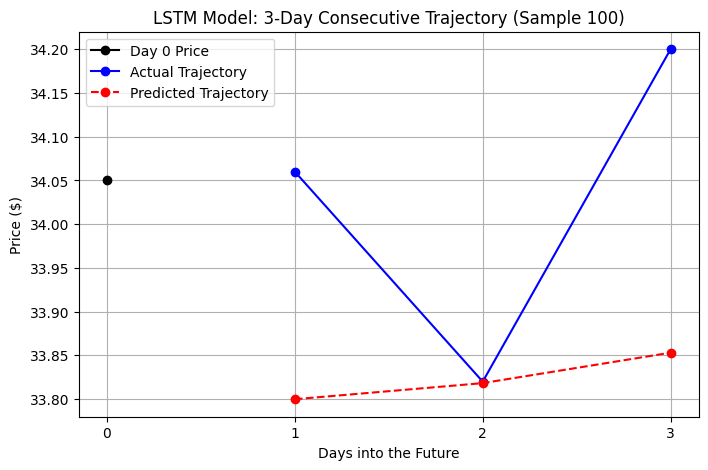

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

y_pred_scaled = model_3.predict(X_test)

y_pred_returns = []
y_test_returns = []

current_idx = 0
for scaler_y, num_samples in test_scalers:
    if num_samples <= 0: continue

    company_y_pred_scaled = y_pred_scaled[current_idx : current_idx + num_samples]
    company_y_test_scaled = y_test[current_idx : current_idx + num_samples]

    # We must reshape to (-1, 1) to inverse transform, then reshape back to (-1, k)
    company_y_pred = scaler_y.inverse_transform(company_y_pred_scaled.reshape(-1, 1)).reshape(-1, k)
    company_y_test = scaler_y.inverse_transform(company_y_test_scaled.reshape(-1, 1)).reshape(-1, k)

    y_pred_returns.extend(company_y_pred)
    y_test_returns.extend(company_y_test)
    current_idx += num_samples

y_pred_returns = np.array(y_pred_returns)
y_test_returns = np.array(y_test_returns)

# --- RECONSTRUCT PRICES VIA COMPOUNDING ---
# Convert returns to multipliers: (1 + r)
pred_multipliers = 1 + y_pred_returns
test_multipliers = 1 + y_test_returns

# Calculate cumulative product along the k days (axis=1)
pred_cumulative = np.cumprod(pred_multipliers, axis=1)
test_cumulative = np.cumprod(test_multipliers, axis=1)

# Multiply by the base price (Price 0) reshaped to broadcast across the k columns
predicted_prices = test_previous_prices[:, None] * pred_cumulative
actual_prices = test_previous_prices[:, None] * test_cumulative

# Evaluate
mse = mean_squared_error(actual_prices.flatten(), predicted_prices.flatten())
mae = mean_absolute_error(actual_prices.flatten(), predicted_prices.flatten())
print(f"Test MSE (Across all {k} days): {mse:.4f}")
print(f"Test MAE (Across all {k} days): {mae:.4f}")

# --- VISUALIZATION: Plotting a random 3-day sequence ---
sample_idx = 100 # Pick a random 30-day window to visualize its k-day forecast
days_future = np.arange(1, k + 1)

plt.figure(figsize=(8, 5))
# Plot the anchor point (Day 0)
plt.plot(0, test_previous_prices[sample_idx], marker='o', color='black', label='Day 0 Price')

# Plot the k-day trajectory
plt.plot(days_future, actual_prices[sample_idx], marker='o', color='blue', label='Actual Trajectory')
plt.plot(days_future, predicted_prices[sample_idx], marker='o', color='red', linestyle='dashed', label='Predicted Trajectory')

plt.title(f'LSTM Model: {k}-Day Consecutive Trajectory (Sample {sample_idx})')
plt.xlabel('Days into the Future')
plt.ylabel('Price ($)')
plt.xticks(np.arange(0, k + 1))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, RepeatVector, TimeDistributed

# --- 1. CONFIGURATION ---
window_size = 30
k = 3
features = ['Low', 'High', 'Open', 'Close', 'Adjusted Close', 'Volume']

X_train_list, y_train_list = [], []
X_val_list, y_val_list = [], []
X_test_list, y_test_list, test_previous_prices = [], [], []
test_scalers = []

print(f"Preparing data for {k} consecutive days...")

# --- 2. DATA PREPARATION ---
for df in company_data_list:
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
        df = df.sort_values('Date').reset_index(drop=True)

    raw_open_prices = df['Open'].values

    # Calculate 1-day returns
    df_features = df[features].pct_change(fill_method=None)
    df_features['Raw_Open'] = raw_open_prices

    df_features.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_features = df_features.dropna()

    if len(df_features) < window_size + k + 10:
        continue

    feature_cols = [df_features.columns.get_loc(c) for c in features]
    target_idx = df_features.columns.get_loc('Open')
    raw_idx = df_features.columns.get_loc('Raw_Open')

    data_array = df_features.values
    n = len(data_array)
    train_end = int(n * 0.6)
    val_end = int(n * 0.8)

    train_data = data_array[:train_end]
    val_data = data_array[train_end:val_end]
    test_data = data_array[val_end:]

    scaler_X = StandardScaler()
    train_X_scaled = scaler_X.fit_transform(train_data[:, feature_cols])
    val_X_scaled = scaler_X.transform(val_data[:, feature_cols])
    test_X_scaled = scaler_X.transform(test_data[:, feature_cols])

    scaler_y = StandardScaler()
    train_y_scaled = scaler_y.fit_transform(train_data[:, target_idx].reshape(-1, 1))
    val_y_scaled = scaler_y.transform(val_data[:, target_idx].reshape(-1, 1))
    test_y_scaled = scaler_y.transform(test_data[:, target_idx].reshape(-1, 1))

    num_test_samples = len(test_X_scaled) - window_size - k + 1
    if num_test_samples > 0:
        test_scalers.append((scaler_y, num_test_samples))

    # Build sequential targets (k days at once)
    for i in range(len(train_X_scaled) - window_size - k + 1):
        X_train_list.append(train_X_scaled[i : i + window_size])
        y_train_list.append(train_y_scaled[i + window_size : i + window_size + k].flatten())

    for i in range(len(val_X_scaled) - window_size - k + 1):
        X_val_list.append(val_X_scaled[i : i + window_size])
        y_val_list.append(val_y_scaled[i + window_size : i + window_size + k].flatten())

    for i in range(len(test_X_scaled) - window_size - k + 1):
        X_test_list.append(test_X_scaled[i : i + window_size])
        y_test_list.append(test_y_scaled[i + window_size : i + window_size + k].flatten())
        test_previous_prices.append(test_data[i + window_size - 1, raw_idx])

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)
X_val = np.array(X_val_list)
y_val = np.array(y_val_list)
X_test = np.array(X_test_list)
y_test = np.array(y_test_list)
test_previous_prices = np.array(test_previous_prices)

# RESHAPE FOR SEQ2SEQ (Samples, k, 1)
y_train_seq = y_train.reshape(-1, k, 1)
y_val_seq = y_val.reshape(-1, k, 1)
y_test_seq = y_test.reshape(-1, k, 1)

print(f"Data ready! X_train shape: {X_train.shape}, y_train_seq shape: {y_train_seq.shape}")

# --- 3. TRUE SEQ2SEQ ENCODER-DECODER ARCHITECTURE ---
model_3_seq = Sequential([
    # ENCODER
    Input(shape=(window_size, len(features))),
    LSTM(64, activation='relu', return_sequences=False),

    # BRIDGE
    RepeatVector(k),

    # DECODER
    LSTM(32, activation='relu', return_sequences=True),
    Dropout(0.2),

    # OUTPUT
    TimeDistributed(Dense(1))
])

model_3_seq.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.Huber(),
              metrics=['mae'])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print(f"Training True Seq2Seq model for {k} consecutive days...")
history_3_seq = model_3_seq.fit(
    X_train, y_train_seq,
    validation_data=(X_val, y_val_seq),
    epochs=25,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Preparing data for 3 consecutive days...
Data ready! X_train shape: (115652, 30, 6), y_train_seq shape: (115652, 3, 1)
Training True Seq2Seq model for 3 consecutive days...
Epoch 1/25
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 0.2803 - mae: 0.5730 - val_loss: 0.1558 - val_mae: 0.3923
Epoch 2/25
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.2702 - mae: 0.5570 - val_loss: 0.1551 - val_mae: 0.3895
Epoch 3/25
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.2691 - mae: 0.5549 - val_loss: 0.1542 - val_mae: 0.3877
Epoch 4/25
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.2686 - mae: 0.5538 - val_loss: 0.1553 - val_mae: 0.3900
Epoch 5/25
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.2680 - mae: 0.5529 - val_loss: 0.1543 - val_mae: 0.3878
Epoch 6/25
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.2678 - mae: 0.5525 - val_loss: 0.1539 - val_mae: 0.3872
Epoch 7/25
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.2674 - mae: 0.5519 - val_loss: 0.15

1186/1186 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Test MSE (Across all 3 days): 15.8958
Test MAE (Across all 3 days): 1.7817


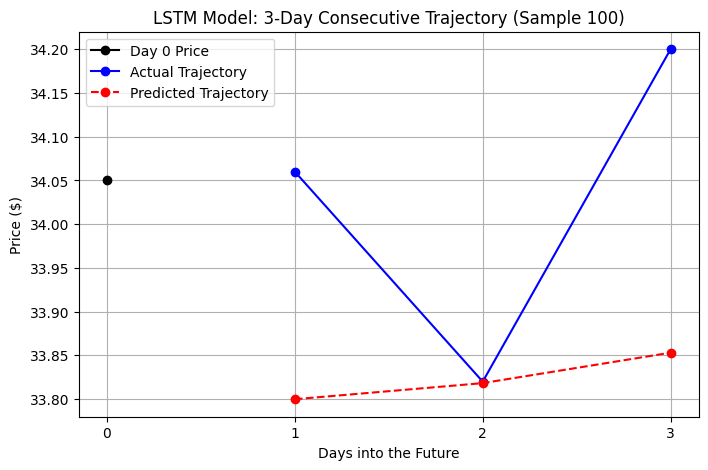

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

y_pred_scaled = model_3.predict(X_test)

y_pred_returns = []
y_test_returns = []

current_idx = 0
for scaler_y, num_samples in test_scalers:
    if num_samples <= 0: continue

    company_y_pred_scaled = y_pred_scaled[current_idx : current_idx + num_samples]
    company_y_test_scaled = y_test[current_idx : current_idx + num_samples]

    # We must reshape to (-1, 1) to inverse transform, then reshape back to (-1, k)
    company_y_pred = scaler_y.inverse_transform(company_y_pred_scaled.reshape(-1, 1)).reshape(-1, k)
    company_y_test = scaler_y.inverse_transform(company_y_test_scaled.reshape(-1, 1)).reshape(-1, k)

    y_pred_returns.extend(company_y_pred)
    y_test_returns.extend(company_y_test)
    current_idx += num_samples

y_pred_returns = np.array(y_pred_returns)
y_test_returns = np.array(y_test_returns)

# --- RECONSTRUCT PRICES VIA COMPOUNDING ---
# Convert returns to multipliers: (1 + r)
pred_multipliers = 1 + y_pred_returns
test_multipliers = 1 + y_test_returns

# Calculate cumulative product along the k days (axis=1)
pred_cumulative = np.cumprod(pred_multipliers, axis=1)
test_cumulative = np.cumprod(test_multipliers, axis=1)

# Multiply by the base price (Price 0) reshaped to broadcast across the k columns
predicted_prices = test_previous_prices[:, None] * pred_cumulative
actual_prices = test_previous_prices[:, None] * test_cumulative

# Evaluate
mse = mean_squared_error(actual_prices.flatten(), predicted_prices.flatten())
mae = mean_absolute_error(actual_prices.flatten(), predicted_prices.flatten())
print(f"Test MSE (Across all {k} days): {mse:.4f}")
print(f"Test MAE (Across all {k} days): {mae:.4f}")

# --- VISUALIZATION: Plotting a random 3-day sequence ---
sample_idx = 100 # Pick a random 30-day window to visualize its k-day forecast
days_future = np.arange(1, k + 1)

plt.figure(figsize=(8, 5))
# Plot the anchor point (Day 0)
plt.plot(0, test_previous_prices[sample_idx], marker='o', color='black', label='Day 0 Price')

# Plot the k-day trajectory
plt.plot(days_future, actual_prices[sample_idx], marker='o', color='blue', label='Actual Trajectory')
plt.plot(days_future, predicted_prices[sample_idx], marker='o', color='red', linestyle='dashed', label='Predicted Trajectory')

plt.title(f'LSTM Model: {k}-Day Consecutive Trajectory (Sample {sample_idx})')
plt.xlabel('Days into the Future')
plt.ylabel('Price ($)')
plt.xticks(np.arange(0, k + 1))
plt.legend()
plt.grid(True)
plt.show()

## GRU

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

window_size = 30
k = 3
features = ['Low', 'High', 'Open', 'Close', 'Volume']

# Temporary lists to hold unscaled windows
X_all, y_all, dates_all, raw_prices_all = [], [], [], []

print(f"1. Building windows for all companies...")

for df in company_data_list:
    if 'Date' not in df.columns:
        continue

    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
    df = df.sort_values('Date').reset_index(drop=True)

    raw_open_prices = df['Open'].values

    # Calculate returns
    df_features = df[features].pct_change(fill_method=None)
    df_features['Raw_Open'] = raw_open_prices

    # Cleanup
    df_features.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_features = df_features.dropna()

    if len(df_features) < window_size + k + 10:
        continue

    feature_cols = [df_features.columns.get_loc(c) for c in features]
    target_idx = df_features.columns.get_loc('Open')
    raw_idx = df_features.columns.get_loc('Raw_Open')
    date_array = df.loc[df_features.index, 'Date'].values # Align dates with cleaned features

    data_array = df_features.values

    # Build windows
    for i in range(len(data_array) - window_size - k + 1):
        X_all.append(data_array[i : i + window_size, feature_cols])

        # Grab next k days
        y_all.append(data_array[i + window_size : i + window_size + k, target_idx])

        # Anchor date: The date at the start of the window
        dates_all.append(date_array[i])

        # Save raw price at the end of the window (T)
        raw_prices_all.append(data_array[i + window_size - 1, raw_idx])

# Convert to Numpy Arrays
X_all = np.array(X_all)
y_all = np.array(y_all)
dates_all = np.array(dates_all)
raw_prices_all = np.array(raw_prices_all)

print(f"2. Performing Global Date Split on {len(X_all)} total windows...")

# Split data
sorted_unique_dates = np.sort(np.unique(dates_all))
total_days = len(sorted_unique_dates)

cut_train = sorted_unique_dates[int(total_days * 0.6)]
cut_val   = sorted_unique_dates[int(total_days * 0.8)]

# Create boolean masks based on calendar dates
train_mask = dates_all < cut_train
val_mask   = (dates_all >= cut_train) & (dates_all < cut_val)
test_mask  = dates_all >= cut_val

# Apply masks
X_train_raw, y_train_raw = X_all[train_mask], y_all[train_mask]
X_val_raw, y_val_raw     = X_all[val_mask], y_all[val_mask]
X_test_raw, y_test_raw   = X_all[test_mask], y_all[test_mask]
test_previous_prices     = raw_prices_all[test_mask]

print(f"3. Scaling data globally to prevent leakage...")

# Scaling data
# Fit the scalers only on the Training set, then transform Val and Test.
# Because X is 3D (samples, window, features), flatten it to 2D for the scaler first, then reshape it back.

scaler_X = StandardScaler()

# Fit on Train
X_train = scaler_X.fit_transform(X_train_raw.reshape(-1, len(features))).reshape(X_train_raw.shape)

# Transform Val & Test
X_val = scaler_X.transform(X_val_raw.reshape(-1, len(features))).reshape(X_val_raw.shape)
X_test = scaler_X.transform(X_test_raw.reshape(-1, len(features))).reshape(X_test_raw.shape)

scaler_y = StandardScaler()

# Fit on Train (y is 2D: samples, k)
y_train = scaler_y.fit_transform(y_train_raw)

# Transform Val & Test
y_val = scaler_y.transform(y_val_raw)
y_test = scaler_y.transform(y_test_raw)

print(f"\nData ready & Leak-Free!")
print(f"Train split ends at: {pd.to_datetime(cut_train).date()}")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test: {y_test.shape}")

1. Building windows for all companies...
2. Performing Global Date Split on 1662849 total windows...
3. Scaling data globally to prevent leakage...

Data ready & Leak-Free!
Train split ends at: 2002-12-27
X_train: (383062, 30, 5), y_train: (383062, 3)
X_test:  (726367, 30, 5),  y_test: (726367, 3)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.regularizers import l2

# 1. Build the GRU Architecture
model_gru = Sequential([
    Input(shape=(window_size, len(features))),

    # GRU layer: fewer parameters than LSTM -> slightly faster training
    GRU(64, return_sequences=False, kernel_regularizer=l2(0.001)),

    Dropout(0.3),

    Dense(32, activation='relu'),

    # Output k neurons for k consecutive days
    Dense(k)
])

# 2. Compile with Huber Loss (to handle extreme market outliers)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model_gru.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.Huber(),
    metrics=['mae', 'mse']
)

model_gru.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,811 (61.76 KB)

 Trainable params: 15,811 (61.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print(f"Starting GRU training for {k}-day forecast...")
history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Starting GRU training for 3-day forecast...
Epoch 1/40
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 0.2491 - mae: 0.5022 - mse: 0.8429 - val_loss: 0.2047 - val_mae: 0.4359 - val_mse: 0.7818
Epoch 2/40
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 0.2439 - mae: 0.4959 - mse: 0.8291 - val_loss: 0.2045 - val_mae: 0.4378 - val_mse: 0.7805
Epoch 3/40
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 0.2432 - mae: 0.4954 - mse: 0.8270 - val_loss: 0.2037 - val_mae: 0.4354 - val_mse: 0.7777
Epoch 4/40
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 0.2428 - mae: 0.4952 - mse: 0.8251 - val_loss: 0.2034 - val_mae: 0.4354 - val_mse: 0.7763
Epoch 5/40
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.2426 - mae: 0.4948 - mse: 0.8243 - val_loss: 0.2031 - val_mae: 0.4353 - val_mse: 0.7753
Epoch 6/40
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 0.2424 - mae: 0.4948 - mse: 0.8237 - val_loss: 0.2035 - val_mae: 0.4364 - val_mse: 0.7764
Epoch 7/40
1497/1497 ━━━━━━━━━━━

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("Generating predictions...")
y_pred_scaled = model_gru.predict(X_test)

# 1. Inverse transform globally
y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)

# 2. Evaluate per horizon (Day 1, Day 2, Day 3)
print(f"\n--- Task 1.3 Evaluation: {k} Consecutive Days ---")

for day in range(k):
    print(f"\nHorizon: T + {day + 1}")
    true_returns = y_test_inv[:, day]
    pred_returns = y_pred_inv[:, day]

    rmse = np.sqrt(mean_squared_error(true_returns, pred_returns))
    mae = mean_absolute_error(true_returns, pred_returns)

    # Directional Accuracy: Did we guess the sign (+ or -) correctly?
    correct_direction = np.sum(np.sign(true_returns) == np.sign(pred_returns))
    total_non_zero = np.sum(true_returns != 0)
    dir_acc = correct_direction / total_non_zero if total_non_zero > 0 else 0

    print(f"  RMSE   : {rmse:.4f}")
    print(f"  MAE    : {mae:.4f}")
    print(f"  DirAcc : {dir_acc:.2%}")

Generating predictions...
22699/22699 ━━━━━━━━━━━━━━━━━━━━ 62s 3ms/step

--- Task 1.3 Evaluation: 3 Consecutive Days ---

Horizon: T + 1
  RMSE   : 0.0328
  MAE    : 0.0117
  DirAcc : 84.64%

Horizon: T + 2
  RMSE   : 0.0476
  MAE    : 0.0237
  DirAcc : 50.32%

Horizon: T + 3
  RMSE   : 0.0477
  MAE    : 0.0237
  DirAcc : 50.11%


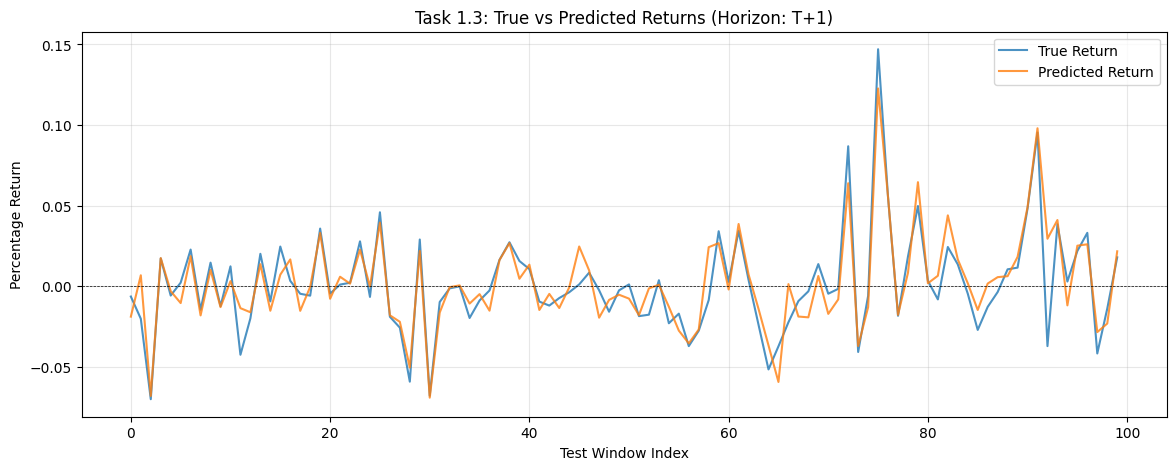

In [ ]:
import matplotlib.pyplot as plt

# Choose which day to visualize (0 = Day 1, 1 = Day 2, 2 = Day 3)
plot_day = 0
num_samples_to_plot = 100
start_idx = 0 # Change this to look at different parts of the test set

true_plot = y_test_inv[start_idx : start_idx + num_samples_to_plot, plot_day]
pred_plot = y_pred_inv[start_idx : start_idx + num_samples_to_plot, plot_day]

plt.figure(figsize=(14, 5))
plt.plot(true_plot, label='True Return', linewidth=1.5, alpha=0.8)
plt.plot(pred_plot, label='Predicted Return', linewidth=1.5, alpha=0.8)
plt.title(f'Task 1.3: True vs Predicted Returns (Horizon: T+{plot_day + 1})')
plt.xlabel('Test Window Index')
plt.ylabel('Percentage Return')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--') # 0% return baseline
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()